<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab #3: Autograd on Logistic Regression (Imbalanced Gradients)</h2>
Semester 1, 2026<br>
</center>

**Due**: 11:59pm on Sunday 15 March, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging. Note that this code will not be run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`).

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

In [1]:
# TODO: Replace with your name and university ID
student_name = "Razeen Wasif"
student_id = "u7283652"

## Disclosure

TODO: document any use of online resources (other than course material) and/or generative AI tools.

In [2]:
# The ANU lab machines will have python and the necessary packages already installed. If you're working
# on your own machine you will need to install python with Jupyter notebook and PyTorch:
#  - Documentation for the PyTorch deep learning library is here: https://pytorch.org/. Follow the
#    installation instructions (for the stable release), being sure to install both `pytorch` and
#    `torchvision`. You will not need access to a GPU for this course but having one may increase
#    computation speed.
#  Browse through the user documentation and tutorials for these libraries.

import sys
import getpass

def is_notebook():
    return 'ipykernel' in sys.modules

import numpy as np
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt

if is_notebook():
    print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
    print("Python Version: {}".format(sys.version))
    print("PyTorch Version: {}".format(torch.__version__))

User: ryujin (Razeen Wasif, u7283652)
Python Version: 3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]
PyTorch Version: 2.10.0+cu128


In [3]:
device = torch.device("cpu")
random_seed = 3242
torch.manual_seed(random_seed)
np.random.seed(random_seed)

## Background

We consider **binary classification** with labels $y \in \{0, 1\}$. Each data point is a feature vector $x \in \mathbb{R}^d$. We model the probability of the positive class using **logistic regression** (a one-neuron network):

$$z^{(i)} = a^\top x^{(i)} + b, \quad h^{(i)} = P(y=1 \mid x^{(i)}; a, b) = \sigma(z^{(i)}) = \frac{1}{1 + e^{-z^{(i)}}},$$

where $a \in \mathbb{R}^d$ and $b \in \mathbb{R}$ are learnable parameters.

**Binary cross-entropy (BCE) loss.** For one example:
$$\ell(h, y) = -(y \log h + (1-y) \log(1-h))$$
where $y \in \{0, 1\}$ is the true label and $h \in (0, 1)$ is computed as above.

We optimise the **empirical loss** (sum form):
$$J(a, b) = \sum_{i=1}^{n} \ell\bigl(h^{(i)}, y^{(i)}\bigr).$$

## Part A: Derivation — Gradients of Logistic Regression with BCE

**(A1) Chain rule derivation.** Starting from $h^{(i)} = \sigma(a^\top x^{(i)} + b)$ and $J(a, b) = \sum_{i=1}^{n} \ell(h^{(i)}, y^{(i)})$, derive closed-form expressions for:

$$\nabla_a J(a, b) \quad \text{and} \quad \frac{\partial J(a, b)}{\partial b}.$$

**(A2) Interpretation.** Show that your expression can be written as a sum of per-example contributions. Identify what each example contributes to the gradient and explain (1–2 sentences) why large feature values and/or many examples from a class can dominate the update direction.

**A1: Derivation**

Starting with the loss function for a single example $(x^{(i)}, y^{(i)})$:

$$\ell(h^{(i)}, y^{(i)}) = - \left[ y^{(i)} \log(h^{(i)}) + (1 - y^{(i)}) \log(1 - h^{(i)}) \right]$$

where $h^{(i)} = \sigma(z^{(i)})$ and $z^{(i)} = a^\top x^{(i)} + b$. Applying the chain rule:

1. **Derivative of Loss w.r.t. Prediction ($h^{(i)}$):**
   $$\frac{\partial \ell}{\partial h^{(i)}} = -\frac{y^{(i)}}{h^{(i)}} + \frac{1 - y^{(i)}}{1 - h^{(i)}} = \frac{h^{(i)} - y^{(i)}}{h^{(i)}(1 - h^{(i)})}$$

2. **Derivative of Prediction w.r.t. Logit ($z^{(i)}$):**
   $$\frac{\partial h^{(i)}}{\partial z^{(i)}} = \sigma(z^{(i)})(1 - \sigma(z^{(i)})) = h^{(i)}(1 - h^{(i)})$$

3. **Derivative of Loss w.r.t. Logit ($z^{(i)}$):**
   $$\frac{\partial \ell}{\partial z^{(i)}} = \frac{\partial \ell}{\partial h^{(i)}} \cdot \frac{\partial h^{(i)}}{\partial z^{(i)}} = (h^{(i)} - y^{(i)})$$

4. **Gradients w.r.t. $a$ and $b$:**
   Since $\nabla_a z^{(i)} = x^{(i)}$ and $\frac{\partial z^{(i)}}{\partial b} = 1$:
   $$\nabla_a \ell = (h^{(i)} - y^{(i)})x^{(i)} \quad \text{and} \quad \frac{\partial \ell}{\partial b} = (h^{(i)} - y^{(i)})$$

Summing over all $n$ examples, the total gradients are:
$$\nabla_a J(a, b) = \sum_{i=1}^{n} (h^{(i)} - y^{(i)})x^{(i)}$$
$$\frac{\partial J(a, b)}{\partial b} = \sum_{i=1}^{n} (h^{(i)} - y^{(i)})$$

**A2: Interpretation**

The total gradient is a sum of per-example contributions, where each contribution is the error $(h^{(i)} - y^{(i)})$ scaled by the feature vector $x^{(i)}$ (for the weights) or $1$ (for the bias). Large feature values dominate the update because they directly multiply the error, causing a larger shift in the corresponding weights. Similarly, many examples from one class can dominate because their collective errors sum up, potentially drowning out the signal from a minority class.

## Part B: Manual Gradients (no autograd)

In [4]:
# --- TASK B1 -------------------------------------------------------------------------------------
# Implement the sigmoid function and BCE loss.

def sigmoid(z: np.ndarray) -> np.ndarray:
    """Computes the sigmoid function element-wise.

    Args:
        z (np.ndarray): Input array of any shape.

    Returns:
        np.ndarray: Sigmoid-transformed values, same shape as z.
    """
    # TODO: implement the sigmoid function. You may add a small epsilon (e.g. 1e-12) inside
    # any logs elsewhere to avoid numerical issues, but for the sigmoid itself use the
    # standard formula: 1 / (1 + exp(-z)).
    return 1 / (1 + np.exp(-z))


def bce_loss(h: np.ndarray, y: np.ndarray) -> float:
    """Computes the binary cross-entropy loss (sum form).

    Args:
        h (np.ndarray): Predicted probabilities, shape (n,).
        y (np.ndarray): Ground truth binary labels, shape (n,).

    Returns:
        float: The total BCE loss summed over all examples.

    Notes:
        Use sum (not mean) form: J = sum_i ell(h_i, y_i).
        Watch for overflow/underflow in the computation. Use the log-sum-exp trick or equivalent to ensure numerical stability.
    """
    # TODO: implement the BCE loss.
    epsilon = 1e-12 
    # clip to avoid log(0) 
    h = np.clip(h, epsilon, 1.0 - epsilon)
    return -np.sum(y * np.log(h) + (1-y) * np.log(1-h))

In [5]:
# Some unit tests for Task B1.

if is_notebook():
    # sigmoid tests
    assert np.isclose(sigmoid(0.0), 0.5), "sigmoid(0) should be 0.5"
    assert sigmoid(100.0) > 0.99, "sigmoid(large) should be close to 1"
    assert sigmoid(-100.0) < 0.01, "sigmoid(-large) should be close to 0"
    print("sigmoid tests passed")

    # bce_loss tests
    h_test = np.array([0.9, 0.1])   # confident and correct
    y_test = np.array([1.0, 0.0])
    loss_val = bce_loss(h_test, y_test)
    print(f"BCE loss (should be small): {loss_val:.4f}")

    h_wrong = np.array([0.1, 0.9])  # confident and wrong
    loss_wrong = bce_loss(h_wrong, y_test)
    print(f"BCE loss (should be large): {loss_wrong:.4f}")
    assert loss_wrong > loss_val, "Wrong predictions should have higher loss"

sigmoid tests passed
BCE loss (should be small): 0.2107
BCE loss (should be large): 4.6052


In [6]:
# --- TASK B1 (continued) -------------------------------------------------------------------------
# Implement the manual gradient function using your analytical formulas from Part A.

def manual_grads(
    a: np.ndarray, b: float, X: np.ndarray, y: np.ndarray
) -> tuple[np.ndarray, float]:
    """Computes gradients of the BCE loss w.r.t. a and b analytically (no autograd).

    Args:
        a (np.ndarray): Weight vector, shape (d,).
        b (float): Bias scalar.
        X (np.ndarray): Feature matrix, shape (n, d).
        y (np.ndarray): Binary labels, shape (n,).

    Returns:
        tuple[np.ndarray, float]: (grad_a, grad_b) where grad_a has shape (d,)
            and grad_b is a float.

    Notes:
        Use only NumPy operations. Do NOT call torch.backward() here.
        Use your analytical expressions derived in Part A.
    """
    # TODO: implement the analytical gradient computation.
    h = sigmoid(X @ a + b)
    grad_a = X.T @ (h - y)
    grad_b = float(np.sum(h - y))
    return grad_a, grad_b

In [7]:
# --- TASK B2 -------------------------------------------------------------------------------------
# Implement one gradient descent step.

def gd_step(
    a: np.ndarray, b: float,
    grad_a: np.ndarray, grad_b: float,
    lr: float
) -> tuple[np.ndarray, float]:
    """Performs one gradient descent update step.

    Args:
        a (np.ndarray): Current weight vector, shape (d,).
        b (float): Current bias scalar.
        grad_a (np.ndarray): Gradient w.r.t. a, shape (d,).
        grad_b (float): Gradient w.r.t. b.
        lr (float): Learning rate (eta > 0).

    Returns:
        tuple[np.ndarray, float]: Updated (a, b).
    """
    # TODO: implement one gradient descent step
    a_new = a - lr * grad_a
    b_new = b - lr * grad_b
    return a_new, b_new

In [8]:
# Some unit tests for Task B1 and B2.

if is_notebook():
    np.random.seed(random_seed)
    n, d = 10, 3
    X_test = np.random.randn(n, d)
    y_test = (np.random.rand(n) > 0.5).astype(float)
    a_test = np.zeros(d)
    b_test = 0.0

    grad_a, grad_b = manual_grads(a_test, b_test, X_test, y_test)
    print(f"grad_a shape: {grad_a.shape}, expected: ({d},)")
    print(f"grad_a: {grad_a}")
    print(f"grad_b: {grad_b}")

    a_new, b_new = gd_step(a_test, b_test, grad_a, grad_b, lr=0.1)
    print(f"\nAfter one GD step with lr=0.1:")
    print(f"a: {a_new}")
    print(f"b: {b_new}")

grad_a shape: (3,), expected: (3,)
grad_a: [-2.17032551  2.02839681 -0.91910446]
grad_b: 1.0

After one GD step with lr=0.1:
a: [ 0.21703255 -0.20283968  0.09191045]
b: -0.1


## Part C: Autograd — Verify PyTorch Matches Manual Gradients

In [9]:
# --- TASK C1 -------------------------------------------------------------------------------------
# Implement the forward pass and BCE loss in PyTorch, then compute gradients with autograd.

def autograd_grads(
    a: np.ndarray, b: float, X: np.ndarray, y: np.ndarray
) -> tuple[np.ndarray, float]:
    """Computes gradients of the BCE loss w.r.t. a and b using torch.autograd.

    Args:
        a (np.ndarray): Weight vector, shape (d,).
        b (float): Bias scalar.
        X (np.ndarray): Feature matrix, shape (n, d).
        y (np.ndarray): Binary labels, shape (n,).

    Returns:
        tuple[np.ndarray, float]: (grad_a, grad_b) as NumPy arrays/scalars,
            where grad_a has shape (d,) and grad_b is a float.

    Notes:
        - Convert inputs to torch tensors with requires_grad=True for a and b.
        - Implement the forward pass: z = X @ a + b, h = sigmoid(z).
        - Compute the BCE loss J (sum form) as a torch scalar.
        - Call J.backward() to compute gradients.
        - Do NOT hard-code the gradient formula here — let PyTorch compute it.
        - Return gradients as NumPy arrays/scalars (use .detach().numpy()).
    """
    # TODO: implement autograd gradient computation.
    a_tensor = torch.tensor(a, requires_grad=True, dtype=torch.float64)
    b_tensor = torch.tensor(b, requires_grad=True, dtype=torch.float64)
    x_tensor = torch.tensor(X, dtype=torch.float64)
    y_tensor = torch.tensor(y, dtype=torch.float64)
    z = x_tensor @ a_tensor + b_tensor 
    loss = F.binary_cross_entropy_with_logits(z, y_tensor, reduction='sum')
    loss.backward()
    grad_a = a_tensor.grad.detach().numpy()
    grad_b = float(b_tensor.grad.detach().numpy())
    return grad_a, grad_b

In [10]:
# --- TASK C2 -------------------------------------------------------------------------------------
# Gradient check: compare manual_grads and autograd_grads on a small random input.

if is_notebook():
    np.random.seed(random_seed)
    n, d = 8, 4
    X_check = np.random.randn(n, d)
    y_check = (np.random.rand(n) > 0.5).astype(float)
    a_check = np.random.randn(d) * 0.1
    b_check = 0.0

    grad_a_manual, grad_b_manual = manual_grads(a_check, b_check, X_check, y_check)
    grad_a_auto,   grad_b_auto   = autograd_grads(a_check, b_check, X_check, y_check)

    diff_a = np.max(np.abs(grad_a_manual - grad_a_auto))
    diff_b = np.abs(grad_b_manual - grad_b_auto)

    print(f"Max |grad_a_manual - grad_a_auto|: {diff_a:.2e}")
    print(f"    |grad_b_manual - grad_b_auto|: {diff_b:.2e}")
    print("(Both should be close to 0, up to floating point precision)")

Max |grad_a_manual - grad_a_auto|: 1.11e-16
    |grad_b_manual - grad_b_auto|: 0.00e+00
(Both should be close to 0, up to floating point precision)


## Part D: Toy Experiment (1D) — Imbalanced vs. Balanced Gradients

We now specialise to $d = 1$ (scalar input $x \in \mathbb{R}$). The model is:
$$z = a x + b, \quad h = \sigma(z).$$

The decision boundary (where $h = 0.5$, i.e., $z = 0$) is $x^\star = -b / a$ (when $a \neq 0$).

**Datasets:**
$$D_{\text{imb}} = \{(1, 0), (9, 1), (10, 1), (11, 1)\}$$
$$D_{\text{bal}} = \{(1, 0), (2, 0), (3, 0), (9, 1), (10, 1), (11, 1)\}$$

**Initialisation:** $a_0 = 0$, $b_0 = 0$, $\eta = 1$.

In [11]:
# Define the two toy datasets (1D: X is shape (n, 1), y is shape (n,))

X_imb      = np.array([[1], [9], [10], [11]], dtype=float)
y_imb      = np.array([0, 1, 1, 1], dtype=float)

X_bal = np.array([[1], [2], [3], [9], [10], [11]], dtype=float)
y_bal = np.array([0, 0, 0, 1, 1, 1], dtype=float)

In [12]:
# --- TASK D1 -------------------------------------------------------------------------------------
# Split the gradient into negative-class and positive-class contributions.
#
# For a dataset D, the gradient w.r.t. a decomposes as:
#   g_a = g_a_pos + g_a_neg
# where
#   g_a_pos = sum over i where y_i=1 of (h_i - 1) * x_i
#   g_a_neg = sum over i where y_i=0 of (h_i - 0) * x_i
#
# TODO: Complete the function below.

def gradient_contributions(
    a: np.ndarray, b: float, X: np.ndarray, y: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Splits the a gradient into positive-class and negative-class contributions.

    Args:
        a (np.ndarray): Weight vector, shape (d,).
        b (float): Bias scalar.
        X (np.ndarray): Feature matrix, shape (n, d).
        y (np.ndarray): Binary labels, shape (n,).

    Returns:
        tuple[np.ndarray, np.ndarray]: (g_a_pos, g_a_neg), each of shape (d,).
    """
    # TODO: compute g_a_pos and g_a_neg.
    h = sigmoid(X @ a + b)
    all_contr = (h - y).reshape(-1, 1) * X 
    g_a_pos = np.sum(all_contr[y == 1], axis=0)
    g_a_neg = np.sum(all_contr[y == 0], axis=0)
    return g_a_pos, g_a_neg

In [13]:
# Compute gradient contributions at initialization (a0=0, b0=0) for both datasets.

if is_notebook():
    a0 = np.array([0.0])
    b0 = 0.0

    g_pos_imb, g_neg_imb = gradient_contributions(a0, b0, X_imb, y_imb)
    g_a_imb, g_b_imb = manual_grads(a0, b0, X_imb, y_imb)

    print("D_imb at (a0, b0):")
    print(f"  g_a_pos = {g_pos_imb}")
    print(f"  g_a_neg = {g_neg_imb}")
    print(f"  g_a     = {g_a_imb}  (should equal pos + neg)")

    g_pos_bal, g_neg_bal = gradient_contributions(a0, b0, X_bal, y_bal)
    g_a_bal, g_b_bal = manual_grads(a0, b0, X_bal, y_bal)

    print("\nD_bal at (a0, b0):")
    print(f"  g_a_pos = {g_pos_bal}")
    print(f"  g_a_neg = {g_neg_bal}")
    print(f"  g_a     = {g_a_bal}  (should equal pos + neg)")

D_imb at (a0, b0):
  g_a_pos = [-15.]
  g_a_neg = [0.5]
  g_a     = [-14.5]  (should equal pos + neg)

D_bal at (a0, b0):
  g_a_pos = [-15.]
  g_a_neg = [3.]
  g_a     = [-12.]  (should equal pos + neg)


In [14]:
# --- TASK D2 -------------------------------------------------------------------------------------
# Two gradient descent steps using manual gradients.
# Run two GD steps on D_imb and D_bal from (a0=0, b0=0) with lr=1.
# Report (a1, b1), (a2, b2) and the corresponding decision boundary x* = -b/a
# (when a != 0) after each step.

if is_notebook():
    lr = 1.0

    # --- D_imb ---
    a, b = np.array([0.0]), 0.0

    # TODO: perform two GD steps on D_imb using manual_grads and gd_step.
    # Print (a1, b1), x*_1, (a2, b2), x*_2.
    ga1, gb1 = manual_grads(a, b, X_imb, y_imb)
    a_1, b_1 = gd_step(a, b, ga1, gb1, lr)
    x_star1_imb = -b_1 / a_1[0] if a_1[0] != 0 else np.nan 
    print(f"Step 1: (a1, b1) = ({a_1}, {b_1}), x*1 = {x_star1_imb}")

    ga2, gb2 = manual_grads(a_1, b_1, X_imb, y_imb)
    a_2, b_2 = gd_step(a_1, b_1, ga2, gb2, lr)
    x_star2_imb = -b_2 /a_2[0] if a_2[0] != 0 else np.nan 
    print(f"Step 2: (a2, b2) = ({a_2}, {b_2}), x*2 = {x_star2_imb}")

    # --- D_bal ---
    a, b = np.array([0.0]), 0.0

    # TODO: perform two GD steps on D_bal using manual_grads and gd_step.
    # Print (a1, b1), x*_1, (a2, b2), x*_2.
    ga1, gb1 = manual_grads(a, b, X_bal, y_bal)
    a_1, b_1 = gd_step(a, b, ga1, gb1, lr)
    x_star1_bal = -b_1 / a_1[0] if a_1[0] != 0 else np.nan 
    print(f"Step 1: (a1, b1) = ({a_1}, {b_1}), x*1 = {x_star1_bal}")

    ga2, gb2 = manual_grads(a_1, b_1, X_bal, y_bal)
    a_2, b_2 = gd_step(a_1, b_1, ga2, gb2, lr)
    x_star2_bal = -b_2 /a_2[0] if a_2[0] != 0 else np.nan 
    print(f"Step 2: (a2, b2) = ({a_2}, {b_2}), x*2 = {x_star2_bal}")

Step 1: (a1, b1) = ([14.5], 1.0), x*1 = -0.06896551724137931
Step 2: (a2, b2) = ([13.50000019], 1.8553910186014377e-07), x*2 = -1.3743636985937904e-08
Step 1: (a1, b1) = ([12.], 0.0), x*1 = -0.0
Step 2: (a2, b2) = ([6.00000614], -2.999993855787646), x*2 = 0.4999984639453385


In [15]:
# --- TASK D3 -------------------------------------------------------------------------------------
# Repeat (D2) using torch autograd. Confirm parameters match the manual update.

if is_notebook():
    lr = 1.0

    # --- D_imb (autograd) ---
    a, b = np.array([0.0]), 0.0

    # TODO: perform two GD steps on D_imb using autograd_grads and gd_step.
    # Print (a1, b1), (a2, b2) and confirm they match the manual values from D2.
    ga1, gb1 = autograd_grads(a, b, X_imb, y_imb)
    a_1, b_1 = gd_step(a, b, ga1, gb1, lr)
    ga2, gb2 = autograd_grads(a_1, b_1, X_imb, y_imb)
    a_2, b_2 = gd_step(a_1, b_1, ga2, gb2, lr)
    print(f"Autograd Result (D_imb): a2={a_2}, b2={b_2}")

    # --- D_bal (autograd) ---
    a, b = np.array([0.0]), 0.0

    ga1, gb1 = autograd_grads(a, b, X_bal, y_bal)
    a_1, b_1 = gd_step(a, b, ga1, gb1, lr)
    ga2, gb2 = autograd_grads(a_1, b_1, X_bal, y_bal)
    a_2, b_2 = gd_step(a_1, b_1, ga2, gb2, lr)
    print(f"Autograd Result (D_bal): a2={a_2}, b2={b_2}")

    # TODO: perform two GD steps on D_bal using autograd_grads and gd_step.
    # Print (a1, b1), (a2, b2) and confirm they match the manual values from D2.
    ...

Autograd Result (D_imb): a2=[13.50000019], b2=1.8553910186014377e-07
Autograd Result (D_bal): a2=[6.00000614], b2=-2.999993855787646


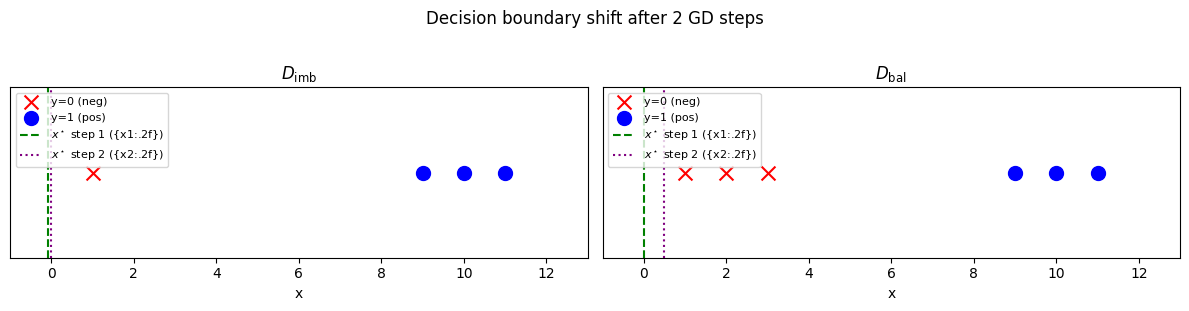

In [16]:
# --- TASK D4 -------------------------------------------------------------------------------------
# 1D visualisation: plot the decision boundary shift on a number line.
#
# For each dataset (D_imb and D_bal), create a plot that:
#   - places negative examples (y=0) and positive examples (y=1) as markers along the x-axis;
#   - draws vertical lines for the decision boundary x* after step 1 and step 2;
#   - includes a title/caption.
# Two separate subplots (one per dataset) are fine.
#
# After the plot, write a short explanation (1-2 sentences) in the markdown cell below:
# what changed between D_imb and D_less_imb, and how did that reflect in the gradient terms?

if is_notebook():
    # TODO: collect x*_1 and x*_2 for both datasets from your D2 calculations above,
    # then produce the 1D number-line plots.

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    for ax, X_data, y_data, x1, x2, title in [
        (axes[0], X_imb, y_imb, x_star1_imb, x_star2_imb, r"$D_{\mathrm{imb}}$"),
        (axes[1], X_bal, y_bal, x_star1_bal, x_star2_bal, r"$D_{\mathrm{bal}}$"),
    ]:
        # Plot data points
        neg_x = X_data[y_data == 0, 0]
        pos_x = X_data[y_data == 1, 0]
        ax.scatter(neg_x, np.zeros_like(neg_x), marker='x', color='red', s=100, label='y=0 (neg)', zorder=3)
        ax.scatter(pos_x, np.zeros_like(pos_x), marker='o', color='blue', s=100, label='y=1 (pos)', zorder=3)

        # TODO: add vertical lines for x*_1 and x*_2.
        # Example (replace with your computed values):
        ax.axvline(x=x1, color='green', linestyle='--', label=r'$x^\star$ step 1 ({x1:.2f})')
        ax.axvline(x=x2, color='purple', linestyle=':', label=r'$x^\star$ step 2 ({x2:.2f})')

        ax.set_yticks([])
        ax.set_xlabel('x')
        ax.set_title(title)
        ax.legend(loc='upper left', fontsize=8)
        ax.set_xlim(-1, 13)

    plt.suptitle('Decision boundary shift after 2 GD steps', y=1.02)
    plt.tight_layout()
    plt.show()

**TODO (D4 caption):** In 1–2 sentences, explain what changed between $D_{\text{imb}}$ and $D_{\text{less-imb}}$ in terms of the gradient terms $g_a^{(+)}$ and $g_a^{(-)}$, and how this is reflected in the decision boundary movement.

In the imbalanced dataset, the positive class has more examples than the negative class causing the positive gradient term to dominate the initial update. This results in the decision boundary shifting more aggresively towards the minority class compared to the balanced dataset where the gradient contributions are more symmetric.

## Part E: Weighted BCE — Correcting Gradient Imbalance

The unweighted BCE loss treats every example equally, so the majority class can dominate the gradients. A standard fix is **class-balanced weighting**: assign each example a weight $w_i$ inversely proportional to its class size:

$$w_i = \frac{n}{2\, n_{c_i}}, \quad \text{where } n_{c_i} = |\{j : y_j = c_i\}|.$$

The **weighted BCE loss** is then:

$$J_w(a, b) = \sum_{i=1}^{n} w_i\, \ell\bigl(h^{(i)}, y^{(i)}\bigr).$$


In [17]:
# --- TASK E2 -------------------------------------------------------------------------------------
# Implement the weighted manual gradient.

def weighted_manual_grads(
    a: np.ndarray, b: float, X: np.ndarray, y: np.ndarray, w: np.ndarray
) -> tuple[np.ndarray, float]:
    """Computes gradients of the weighted BCE loss w.r.t. a and b.

    The weighted loss is: J_w = sum_i w_i * ell(h_i, y_i)

    Args:
        a (np.ndarray): Weight vector, shape (d,).
        b (float): Bias scalar.
        X (np.ndarray): Feature matrix, shape (n, d).
        y (np.ndarray): Binary labels, shape (n,).
        w (np.ndarray): Per-example non-negative weights, shape (n,).

    Returns:
        tuple[np.ndarray, float]: (grad_a, grad_b).

    Notes:
        Use only NumPy. Do NOT call torch.backward() here.
    """
    # TODO: implement the weighted gradient.
    h = sigmoid(X @ a + b) 
    weighted_error = w * (h-y)
    grad_a = X.T @ weighted_error
    grad_b = float(np.sum(weighted_error))
    return grad_a, grad_b

In [18]:
# --- TASK E3 -------------------------------------------------------------------------------------
# Implement the weighted autograd gradient and verify it matches weighted_manual_grads.

def weighted_autograd_grads(
    a: np.ndarray, b: float, X: np.ndarray, y: np.ndarray, w: np.ndarray
) -> tuple[np.ndarray, float]:
    """Computes gradients of the weighted BCE loss using torch.autograd.

    Args:
        a (np.ndarray): Weight vector, shape (d,).
        b (float): Bias scalar.
        X (np.ndarray): Feature matrix, shape (n, d).
        y (np.ndarray): Binary labels, shape (n,).
        w (np.ndarray): Per-example non-negative weights, shape (n,).

    Returns:
        tuple[np.ndarray, float]: (grad_a, grad_b).

    Notes:
        Use the numerically stable per-element loss:
          per_example = max(z, 0) - z*y + log1p(exp(-|z|))
        then J = (w * per_example).sum() before calling backward().
    """
    # TODO: implement.
    a_tensor = torch.tensor(a, requires_grad=True, dtype=torch.float64)
    b_tensor = torch.tensor(b, requires_grad=True, dtype=torch.float64)
    x_tensor = torch.tensor(X, dtype=torch.float64)
    y_tensor = torch.tensor(y, dtype=torch.float64)
    w_tensor = torch.tensor(w, dtype=torch.float64)
    z = x_tensor @ a_tensor + b_tensor 
    per_example_loss = F.binary_cross_entropy_with_logits(z, y_tensor, reduction='none')
    total_loss = (w_tensor * per_example_loss).sum()
    total_loss.backward()
    grad_a = a_tensor.grad.detach().numpy()
    grad_b = float(b_tensor.grad.detach().numpy())
    return grad_a, grad_b

if is_notebook():
    np.random.seed(random_seed)
    n_c, d_c = 8, 4
    X_c = np.random.randn(n_c, d_c)
    y_c = (np.random.rand(n_c) > 0.5).astype(float)
    a_c = np.random.randn(d_c) * 0.1
    b_c = 0.0
    w_c = np.random.rand(n_c) + 0.1

    gm, gbm = weighted_manual_grads(a_c, b_c, X_c, y_c, w_c)
    ga, gba = weighted_autograd_grads(a_c, b_c, X_c, y_c, w_c)
    print(f"Max |weighted grad_a diff|: {np.max(np.abs(gm - ga)):.2e}")
    print(f"    |weighted grad_b diff|: {np.abs(gbm - gba):.2e}")
    print("(Both should be close to 0)")

Max |weighted grad_a diff|: 5.55e-17
    |weighted grad_b diff|: 2.22e-16
(Both should be close to 0)


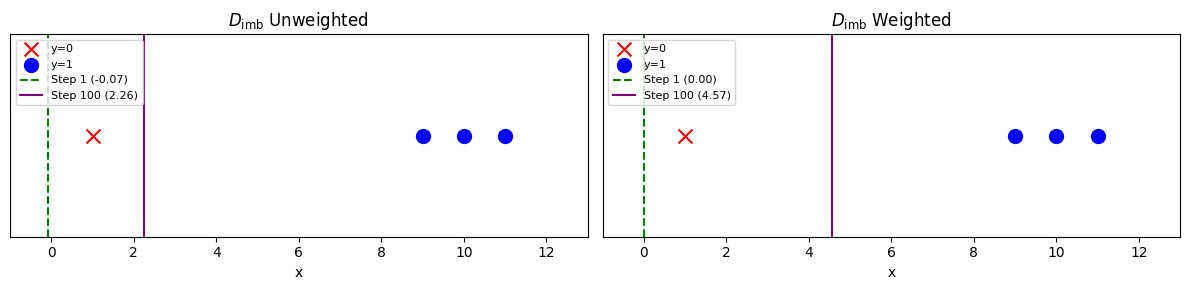

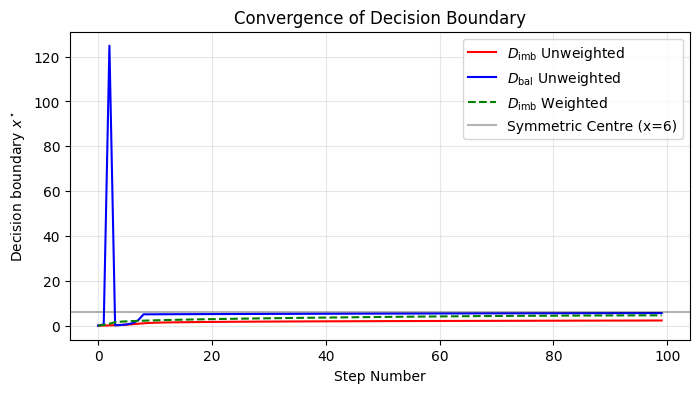

In [19]:
# --- TASK E4 -------------------------------------------------------------------------------------
# Run a weighted GD experiment on D_imb and produce two plots:
#
# Plot 1 (number line): step-1 vs step-N decision boundary for
#   - D_imb unweighted  (left subplot)
#   - D_imb weighted    (right subplot)
#
# Plot 2 (convergence): x* vs step number on the same axes for three cases:
#   - D_imb unweighted
#   - D_bal unweighted
#   - D_imb weighted
#
# Use n_steps_e=100, lr=1. For class-balanced weights: w_i = n / (2 * n_{class_i}).
# (Hint: both the weighted and unweighted losses should eventually converge — what differs?)

if is_notebook():
    n_steps_e = 100
    lr = 1.0

    # TODO: compute class-balanced weights for D_imb.
    w_imb = np.where(y_imb == 0, 4.0 / (2 * 1.0), 4.0 / (2 * 3.0))

    # TODO: implement collect_weighted_steps.
    def collect_weighted_steps(X, y, w, lr=1.0, n_steps=100):
        a_curr, b_curr = np.array([0.0]), 0.0 
        x_stars = []
        for _ in range(n_steps):
            ga, gb = weighted_manual_grads(a_curr, b_curr, X, y, w)
            a_curr, b_curr = gd_step(a_curr, b_curr, ga, gb, lr)
            x_stars.append(-b_curr / a_curr[0] if a_curr[0] != 0 else np.nan)
        return np.array(x_stars)

    hist_imb_unw  = collect_weighted_steps(X_imb, y_imb, np.ones_like(y_imb), lr=lr, n_steps=n_steps_e)  # D_imb unweighted
    hist_bal_unw = collect_weighted_steps(X_bal, y_bal, np.ones_like(y_bal), lr=lr, n_steps=n_steps_e)  # D_less_imb unweighted
    hist_imb_w    = collect_weighted_steps(X_imb, y_imb, w_imb, lr=lr, n_steps=n_steps_e)  # D_imb weighted

    # TODO: Plot 1 — number-line plot (step 1 vs step N, unweighted vs weighted).
    fig, axes = plt.subplots(1, 2, figsize=(12,3))
    for ax, hist, title in [
        (axes[0], hist_imb_unw, r"$D_{\mathrm{imb}}$ Unweighted"),
        (axes[1], hist_imb_w, r"$D_{\mathrm{imb}}$ Weighted"),
    ]:
        neg_x = X_imb[y_imb == 0, 0] 
        pos_x = X_imb[y_imb == 1, 0] 
        ax.scatter(neg_x, np.zeros_like(neg_x), marker='x', color='red', s=100, label='y=0', zorder=3)
        ax.scatter(pos_x, np.zeros_like(pos_x), marker='o', color='blue', s=100, label='y=1', zorder=3)
        ax.axvline(x=hist[0], color='green', linestyle='--', label=f'Step 1 ({hist[0]:.2f})')
        ax.axvline(x=hist[-1], color='purple', linestyle='-', label=f'Step {n_steps_e} ({hist[-1]:.2f})')
        ax.set_yticks([])
        ax.set_xlabel('x')
        ax.set_title(title)
        ax.legend(loc='upper left', fontsize=8)
        ax.set_xlim(-1, 13)
    plt.tight_layout()
    plt.show()

    # TODO: Plot 2 — convergence plot (x* vs step, all three cases).
    plt.figure(figsize=(8,4))
    plt.plot(hist_imb_unw, label=r"$D_{\mathrm{imb}}$ Unweighted", color='red')
    plt.plot(hist_bal_unw, label=r"$D_{\mathrm{bal}}$ Unweighted", color='blue')
    plt.plot(hist_imb_w, label=r"$D_{\mathrm{imb}}$ Weighted", color='green', linestyle='--')
    plt.axhline(6.0, color='black', alpha=0.3, label='Symmetric Centre (x=6)')
    plt.xlabel('Step Number')
    plt.ylabel(r'Decision boundary $x^\star$')
    plt.title('Convergence of Decision Boundary')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

**TODO (E4 caption):** In 2–3 sentences, explain: (1) whether both methods eventually converge to the same boundary and why, and (2) how the class-balanced weights change the gradient contributions $g_a^{(+)}$ and $g_a^{(-)}$ to produce faster convergence.

Both methods eventually converge to the same boundary because given enough steps, the loss will eventually be minimized at the symmetric centre of the clusters. However the class-balanced weights produce much faster convergence by scaling up the minority class's gradient contribution, effectively making the initial update much more balanced.